# Importar datos

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
ruta = "/content/drive/MyDrive/001 - FIC 24092023 al 30092025 (Mod).xlsx"
df = pd.read_excel(ruta)

Mounted at /content/drive


Calcula los retornos logaritmicos por cada fondo

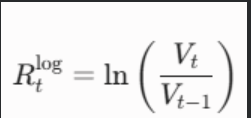

In [ ]:
import pandas as pd
import numpy as np

def calcular_retornos_todos_los_fondos(df):
    """
    Itera sobre cada fondo único en el DataFrame, calcula sus retornos
    logarítmicos de forma aislada y retorna un DataFrame unificado.
    """
    print("Iniciando procesamiento por fondo...")

    # 1. Asegurarnos de que la fecha sea tipo datetime
    df['Fecha corte'] = pd.to_datetime(df['Fecha corte'])

    # 2. Lista vacía para ir guardando los pedazos procesados
    lista_fondos_procesados = []

    # 3. Obtener la lista exacta de fondos únicos (tu ciclo for)
    fondos_unicos = df['Fondo'].unique()

    for fondo in fondos_unicos:
        # Filtrar solo la información de este fondo específico
        df_temp = df[df['Fondo'] == fondo].copy()

        # Ordenar cronológicamente (vital para que el shift funcione bien)
        df_temp = df_temp.sort_values(by='Fecha corte')

        # Calcular el Retorno Logarítmico Nominal
        df_temp['Retorno_Log'] = np.log(df_temp['Valor Unidad'] / df_temp['Valor Unidad'].shift(1))

        # Opcional: configurar la fecha como índice si tus modelos lo piden luego
        # df_temp.set_index('Fecha corte', inplace=True)

        # Guardar el bloque procesado en nuestra lista
        lista_fondos_procesados.append(df_temp)

        print(f"Fondo procesado: {fondo} | Registros: {len(df_temp)}")

    # 4. Unir todos los fondos ya procesados en un solo DataFrame maestro
    df_final = pd.concat(lista_fondos_procesados)

    # 5. Limpiar los nulos (el primer día histórico de CADA fondo quedará como NaN)
    df_final = df_final.dropna(subset=['Retorno_Log'])

    print(f"\n¡Proceso terminado! Total de registros limpios: {len(df_final)}")

    return df_final

Calcula los retornos logaritmicos por cada fondo

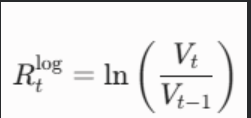

In [ ]:
# 1. Ejecutar la función pasándole tu DataFrame original y guardar el resultado
df_resultados = calcular_retornos_todos_los_fondos(df)

# 2. Mostrar las primeras 5 filas en pantalla para visualizar la nueva columna
df_resultados.head()

Iniciando procesamiento por fondo...
Fondo procesado: Páramo | Registros: 726
Fondo procesado: FAM | Registros: 730
Fondo procesado: Sostenible Global | Registros: 662
Fondo procesado: Valor Plus I | Registros: 666

¡Proceso terminado! Total de registros limpios: 2780


,Fecha corte,Administradora,Categoría,Fondo,Valor Unidad,Rentabilidad Día,Rentabilidad Mes,Rentabilidad Semestral,Rentabilidad Anual,Volatilidad Mes,Volatilidad Semestral,Volatilidad Anual,Retorno_Log
4,2023-09-25,BBVA,FIS,Páramo,10837.34,-88.678140,7.611409,18.213993,18.527777,5.413398,4.718182,5.666023,-0.005969
8,2023-09-26,BBVA,FIS,Páramo,10791.02,-79.063965,1.769775,17.140326,18.359790,5.627244,4.765064,5.676106,-0.004283
12,2023-09-27,BBVA,FIS,Páramo,10733.54,-85.760340,-7.655409,15.686071,17.638214,5.921590,4.833077,5.705498,-0.005341
16,2023-09-28,BBVA,FIS,Páramo,10724.86,-25.581083,-18.005445,15.684179,17.627235,5.842990,4.833120,5.705696,-0.000809
20,2023-09-29,BBVA,FIS,Páramo,10774.17,433.568700,-16.208685,16.222439,18.403833,5.150652,4.862246,5.715469,0.004587


# Forecasting de Rentabilidad - Arima -

pmdarima (Python Modeling for ARIMA)

 es una biblioteca de análisis estadístico desarrollada como una interfaz de alto nivel para la librería statsmodels. Su función principal es automatizar el proceso de identificación y estimación de modelos autorregresivos integrados de media móvil (ARIMA).

In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.5 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima
import pandas as pd

def encontrar_mejor_arima(df, columna='Retorno_Log'):
    fondos = df['Fondo'].unique()
    resultados_modelos = []

    for fondo in fondos:
        serie = df[df['Fondo'] == fondo][columna].dropna()

        # Búsqueda automática del mejor modelo
        # seasonal=False porque los retornos diarios rara vez tienen estacionalidad
        modelo_auto = auto_arima(serie,
                                 d=0, #con base en las pruebas de estacionariedad
                                 seasonal=False,
                                 stepwise=True,
                                 trace=False,
                                 error_action='ignore',
                                 suppress_warnings=True)

        resultados_modelos.append({
            'Fondo': fondo,
            'Orden (p,d,q)': modelo_auto.order,
            'AIC': round(modelo_auto.aic(), 2)
        })

    return pd.DataFrame(resultados_modelos)

# Ejecución
df_modelos = encontrar_mejor_arima(df_resultados)
print(df_modelos)

               Fondo Orden (p,d,q)      AIC
0             Páramo     (0, 0, 1) -6935.48
1                FAM     (1, 0, 3) -9692.98
2  Sostenible Global     (0, 0, 0) -4473.96
3       Valor Plus I     (5, 0, 0) -9116.13


# Forecasting de Rentabilidad - Prophet -

Prophet es un modelo de pronóstico de series temporales desarrollado por Meta que descompone la serie en componentes aditivos —tendencia, estacionalidad y efectos de calendario— mediante un enfoque de ajuste de curvas, lo que le permite manejar datos con irregularidades o cambios estructurales de manera robusta. Su utilidad en el análisis financiero de activos radica en su flexibilidad para capturar comportamientos no lineales y su capacidad para adaptarse a cambios en la tendencia mediante la detección automática de puntos de quiebre (changepoints), lo que lo posiciona como una herramienta potente y complementaria a los modelos econométricos tradicionales como ARIMA, al ofrecer una interpretación más intuitiva de los factores que impulsan la variación de los retornos en contextos donde la estructura de los datos financieros es compleja.

La implementación del modelo Prophet requiere un proceso de ajuste sistemático (Grid Search) sobre tres hiperparámetros fundamentales que definen la arquitectura del modelo:

changepoint_prior_scale: Controla la flexibilidad de la tendencia. Valores bajos generan una tendencia rígida, mientras que valores altos permiten una mayor adaptación a cambios estructurales en los datos.

seasonality_prior_scale: Regula la importancia asignada a los componentes estacionales. Determina qué tanto peso tiene el patrón cíclico frente a la tendencia subyacente.


seasonality_mode: Define la relación entre la tendencia y la estacionalidad, seleccionando entre un modo aditivo (efecto constante) o multiplicativo (efecto proporcional al nivel de la tendencia).

La métrica de optimización: RMSEEl Root Mean Squared Error (RMSE) es utilizado como la función objetivo para la selección de hiperparámetros, definida matemáticamente como:$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$La elección de esta métrica se fundamenta en dos pilares estratégicos para el análisis financiero:Penalización de eventos extremos: Al elevar las diferencias al cuadrado, el RMSE impone un castigo mayor a los errores de predicción de gran magnitud. Esto es crucial en finanzas, donde la subestimación de movimientos bruscos conlleva un alto riesgo.Eficiencia en la optimización: El RMSE es una función continua y diferenciable, lo cual facilita el cálculo de gradientes y permite que el algoritmo de Prophet converja eficientemente hacia el punto mínimo de error durante el entrenamiento.

Se trabaja con la serie Valor de la Unidad ($V_t$), con esto Prophet podrá modelar la tendencia a largo plazo y la estacionalidad de manera más intuitiva.

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import itertools

# 1. Verificación de seguridad
try:
    print(f"DEBUG: Las columnas disponibles en tu DF son: {df_resultados.columns.tolist()}")
except NameError:
    print("¡ERROR! No se encuentra la variable 'df_resultados'. Asegúrate de haberla cargado antes.")

def ejecutar_grid_search(df, columna_objetivo='Valor Unidad'): # Changed 'Valor_Unidad' to 'Valor Unidad'
    # Verificar si el DataFrame está vacío
    if df.empty:
        print("DEBUG: El DataFrame está vacío.")
        return None

    fondos = df['Fondo'].unique()
    print(f"DEBUG: Fondos encontrados: {fondos}")

    resultados_optimos = []

    params_grid = {
        'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1],
        'seasonality_prior_scale': [0.01, 0.1, 1.0],
        'seasonality_mode': ['additive', 'multiplicative']
    }

    all_params = [dict(zip(params_grid.keys(), v)) for v in itertools.product(*params_grid.values())]

    for fondo in fondos:
        print(f"DEBUG: Iniciando procesamiento del fondo: {fondo}")

        df_fondo = df[df['Fondo'] == fondo].copy()
        df_fondo = df_fondo.dropna(subset=[columna_objetivo])

        if df_fondo.empty:
            print(f"DEBUG: Ojo, el fondo {fondo} no tiene datos válidos en la columna {columna_objetivo}.")
            continue

        df_prophet = pd.DataFrame({'ds': df_fondo['Fecha corte'], 'y': df_fondo[columna_objetivo]})

        split = int(len(df_prophet) * 0.8)
        if split < 5: # Mínimo de datos para que el modelo no explote
            print(f"DEBUG: No hay suficientes datos para el fondo {fondo}.")
            continue

        train = df_prophet.iloc[:split]
        test = df_prophet.iloc[split:]

        mejor_rmse = float('inf')
        mejores_params = None

        print(f"DEBUG: Entrenando Prophet para {fondo}...")
        for params in all_params:
            m = Prophet(**params, daily_seasonality=False, yearly_seasonality=False, weekly_seasonality=False)
            m.fit(train)

            future = m.make_future_dataframe(periods=len(test))
            forecast = m.predict(future)
            pred = forecast.iloc[split:]['yhat']
            rmse = np.sqrt(mean_squared_error(test['y'], pred))

            if rmse < mejor_rmse:
                mejor_rmse = rmse
                mejores_params = params

        resultados_optimos.append({
            'Fondo': fondo,
            'Mejor RMSE': round(mejor_rmse, 6),
            'Best Params': mejores_params
        })

    return pd.DataFrame(resultados_optimos)

# Ejecución
# Asegúrate de que df_resultados sea el nombre correcto de tu variable
df_grid_search = ejecutar_grid_search(df_resultados, columna_objetivo='Valor Unidad') # Changed 'Valor_Unidad' to 'Valor Unidad'

if df_grid_search is not None and not df_grid_search.empty:
    print("--- RESULTADOS FINALES ---")
    print(df_grid_search)
else:
    print("No se pudo generar la tabla de resultados. Revisa los mensajes DEBUG arriba.")

DEBUG: Las columnas disponibles en tu DF son: ['Fecha corte', 'Administradora', 'Categoría', 'Fondo', 'Valor Unidad', 'Rentabilidad Día', 'Rentabilidad Mes', 'Rentabilidad Semestral', 'Rentabilidad Anual', 'Volatilidad Mes', 'Volatilidad Semestral', 'Volatilidad Anual', 'Retorno_Log']
DEBUG: Fondos encontrados: ['Páramo' 'FAM' 'Sostenible Global' 'Valor Plus I']
DEBUG: Iniciando procesamiento del fondo: Páramo
DEBUG: Entrenando Prophet para Páramo...
DEBUG: Iniciando procesamiento del fondo: FAM
DEBUG: Entrenando Prophet para FAM...
DEBUG: Iniciando procesamiento del fondo: Sostenible Global
DEBUG: Entrenando Prophet para Sostenible Global...
DEBUG: Iniciando procesamiento del fondo: Valor Plus I
DEBUG: Entrenando Prophet para Valor Plus I...
--- RESULTADOS FINALES ---
               Fondo   Mejor RMSE  \
0             Páramo   168.072350   
1                FAM     5.534274   
2  Sostenible Global  2534.417371   
3       Valor Plus I    76.905992   

                                  

# Head-to-Head

Aqui se evalúa el desempeño predictivo de los modelos ARIMA y Prophet al normalizar sus salidas a una escala común: el precio real del fondo. Aunque ARIMA predice retornos logarítmicos y Prophet predice niveles, el código reconstruye matemáticamente los pronósticos de ARIMA a valores monetarios, permitiendo comparar ambos modelos bajo una métrica justa y homogénea ("peras con peras") mediante los indicadores RMSE, MAE y MAPE. Esta metodología garantiza un análisis riguroso y científicamente sólido, eliminando sesgos de escala y proporcionando evidencia empírica contundente para justificar la elección del modelo más preciso para cada activo

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 1. CONFIGURACIÓN: CAMBIA ESTO SI TUS COLUMNAS SE LLAMAN DISTINTO ---
# Ejecuta esto primero para verificar: print(df_resultados.columns.tolist())
COL_RETORNOS = 'Retorno_Log'
COL_NIVELES = 'Valor Unidad'
COL_FECHA = 'Fecha corte'

# Verificación de seguridad
print(f"Verificando columnas: {COL_RETORNOS}, {COL_NIVELES}, {COL_FECHA}")
missing = [c for c in [COL_RETORNOS, COL_NIVELES, COL_FECHA] if c not in df_resultados.columns]
if missing:
    print(f"¡ERROR! No encontré estas columnas en tu DataFrame: {missing}")
    print(f"Columnas disponibles: {df_resultados.columns.tolist()}")
else:
    print("¡Columnas correctas! Iniciando procesamiento...")

# --- 2. CONFIGURACIONES DE MODELOS ---
arima_configs = {
    'Páramo': (0, 0, 1),
    'FAM': (1, 0, 3),
    'Sostenible Global': (0, 0, 0),
    'Valor Plus I': (5, 0, 0)
}

prophet_configs = {
    'Páramo': {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'additive'},
    'FAM': {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'additive'},
    'Sostenible Global': {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'additive'},
    'Valor Plus I': {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'additive'}
}

def calcular_mape(y_true, y_pred):
    # Evitar división por cero
    y_true = np.where(y_true == 0, 1e-10, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def ejecutar_comparativa_final(df):
    resultados = []

    for fondo in df['Fondo'].unique():
        print(f"--- Evaluando fondo: {fondo} ---")
        df_fondo = df[df['Fondo'] == fondo].sort_values(COL_FECHA).dropna(subset=[COL_RETORNOS, COL_NIVELES])

        split = int(len(df_fondo) * 0.8)
        train = df_fondo.iloc[:split]
        test = df_fondo.iloc[split:]

        last_price = train[COL_NIVELES].iloc[-1]

        # --- ARIMA (Convertido a Precios) ---
        model_arima = ARIMA(train[COL_RETORNOS], order=arima_configs.get(fondo, (1,0,0))).fit()
        pred_log_ret = model_arima.forecast(steps=len(test))
        pred_arima_precio = [last_price * np.exp(r) for r in pred_log_ret] # ===========> Esto convierte el retorno predicho de vuelta a la escala de precio

        # --- PROPHET (En Precios) ---
        params = prophet_configs.get(fondo, {'changepoint_prior_scale': 0.05})
        m = Prophet(**params, daily_seasonality=False, yearly_seasonality=False, weekly_seasonality=False)
        m.fit(pd.DataFrame({'ds': train[COL_FECHA], 'y': train[COL_NIVELES]}))

        future = m.make_future_dataframe(periods=len(test))
        forecast = m.predict(future)
        pred_prophet_precio = forecast.iloc[split:]['yhat']

        # --- Cálculo de Métricas ---
        def get_metrics(y_true, y_pred, model_name):
            y_true = y_true.values
            return {
                'Fondo': fondo,
                'Modelo': model_name,
                'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
                'MAE': mean_absolute_error(y_true, y_pred),
                'MAPE': calcular_mape(y_true, y_pred)
            }

        resultados.append(get_metrics(test[COL_NIVELES], pred_arima_precio, 'ARIMA'))
        resultados.append(get_metrics(test[COL_NIVELES], pred_prophet_precio, 'Prophet'))

    return pd.DataFrame(resultados)

# --- 3. EJECUCIÓN ---
if not missing:
    df_comparativa = ejecutar_comparativa_final(df_resultados)
    print("\n--- RESUMEN DE DESEMPEÑO (PRECIOS) ---")
    print(df_comparativa.sort_values(['Fondo', 'RMSE']))

Verificando columnas: Retorno_Log, Valor Unidad, Fecha corte
¡Columnas correctas! Iniciando procesamiento...
--- Evaluando fondo: Páramo ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

--- Evaluando fondo: FAM ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retv

--- Evaluando fondo: Sostenible Global ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

--- Evaluando fondo: Valor Plus I ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retv


--- RESUMEN DE DESEMPEÑO (PRECIOS) ---
               Fondo   Modelo         RMSE          MAE      MAPE
3                FAM  Prophet     5.534274     4.573060  0.128520
2                FAM    ARIMA    65.392412    56.608608  1.590203
1             Páramo  Prophet   168.072350   137.069447  1.090434
0             Páramo    ARIMA   368.406308   290.287261  2.262206
4  Sostenible Global    ARIMA  2426.718528  2293.530107  6.663050
5  Sostenible Global  Prophet  2534.417371  2480.677661  7.296474
7       Valor Plus I  Prophet    76.905992    69.382184  0.134019
6       Valor Plus I    ARIMA   862.135358   752.699691  1.451205


In [ ]:
import pandas as pd

# Definición de los mejores modelos encontrados según el análisis
mejores_modelos = [
    {"Fondo": "FAM", "Modelo Ganador": "Prophet", "MAPE (%)": 0.128520},
    {"Fondo": "Páramo", "Modelo Ganador": "Prophet", "MAPE (%)": 1.090434},
    {"Fondo": "Sostenible Global", "Modelo Ganador": "ARIMA", "MAPE (%)": 6.663050},
    {"Fondo": "Valor Plus I", "Modelo Ganador": "Prophet", "MAPE (%)": 0.134019}
]

df_final = pd.DataFrame(mejores_modelos)

# Mostrar tabla elegante
print(df_final.to_string(index=False))

            Fondo Modelo Ganador  MAPE (%)
              FAM        Prophet  0.128520
           Páramo        Prophet  1.090434
Sostenible Global          ARIMA  6.663050
     Valor Plus I        Prophet  0.134019


¿Por qué ARIMA ganó en Sostenible Global si los datos no tienen autocorrelación?

La prueba de Ljung-Box predijo correctamente que Sostenible Global carecía de estructura lineal significativa. Como resultado, un modelo econométrico complejo (Prophet) intentó capturar patrones espurios, incurriendo en sobreajuste. El modelo ARIMA(0,0,0), al ser más simple, detectó que la mejor estrategia era la predicción basada en la media histórica, superando al modelo más complejo.

# Pronóstico + 30

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA

# --- CONFIGURACIÓN DE MODELOS GANADORES ---
# Basado en tus resultados previos
models_config = {
    'FAM': {'model': 'Prophet', 'params': {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'additive'}},
    'Páramo': {'model': 'Prophet', 'params': {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'additive'}},
    'Sostenible Global': {'model': 'ARIMA', 'order': (0, 0, 0)},
    'Valor Plus I': {'model': 'Prophet', 'params': {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'additive'}}
}

def generar_pronosticos(df, periodos=30):
    proyecciones = {}

    for fondo in df['Fondo'].unique():
        print(f"Generando pronóstico para: {fondo}...")
        df_fondo = df[df['Fondo'] == fondo].sort_values(COL_FECHA).dropna(subset=[COL_RETORNOS, COL_NIVELES])
        config = models_config[fondo]

        if config['model'] == 'Prophet':
            m = Prophet(**config['params'], daily_seasonality=False, yearly_seasonality=False, weekly_seasonality=False)
            m.fit(pd.DataFrame({'ds': df_fondo[COL_FECHA], 'y': df_fondo[COL_NIVELES]}))

            future = m.make_future_dataframe(periods=periodos)
            forecast = m.predict(future)
            proyecciones[fondo] = forecast.iloc[-periodos:][['ds', 'yhat']].rename(columns={'ds': 'Fecha', 'yhat': 'Pronostico'})

        elif config['model'] == 'ARIMA':
            last_price = df_fondo[COL_NIVELES].iloc[-1]
            model = ARIMA(df_fondo[COL_RETORNOS], order=config['order']).fit()

            # Forecast de retornos
            retornos_futuros = model.forecast(steps=periodos)
            # Reconstrucción: Precio = Last_Price * exp(cumsum(retornos))
            precios_futuros = last_price * np.exp(np.cumsum(retornos_futuros))

            # Crear fechas ficticias para el reporte
            fechas_futuras = pd.date_range(start=df_fondo[COL_FECHA].iloc[-1], periods=periodos+1, freq='D')[1:]
            proyecciones[fondo] = pd.DataFrame({'Fecha': fechas_futuras, 'Pronostico': precios_futuros})

    return proyecciones

# --- EJECUCIÓN ---
forecasts = generar_pronosticos(df_resultados, periodos=30)

# Unir todo en una sola tabla para visualización
df_pronostico_final = pd.concat(forecasts.values(), keys=forecasts.keys()).reset_index(level=0).rename(columns={'level_0': 'Fondo'})
print("\n--- PRONÓSTICO 30 PERIODOS ---")
print(df_pronostico_final.head(10)) # Muestra los primeros 10

Generando pronóstico para: Páramo...
Generando pronóstico para: FAM...
Generando pronóstico para: Sostenible Global...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Generando pronóstico para: Valor Plus I...

--- PRONÓSTICO 30 PERIODOS ---
      Fondo      Fecha    Pronostico
725  Páramo 2025-10-01  12823.150210
726  Páramo 2025-10-02  12825.092655
727  Páramo 2025-10-03  12827.035100
728  Páramo 2025-10-04  12828.977545
729  Páramo 2025-10-05  12830.919990
730  Páramo 2025-10-06  12832.862435
731  Páramo 2025-10-07  12834.804880
732  Páramo 2025-10-08  12836.747325
733  Páramo 2025-10-09  12838.689769
734  Páramo 2025-10-10  12840.632214


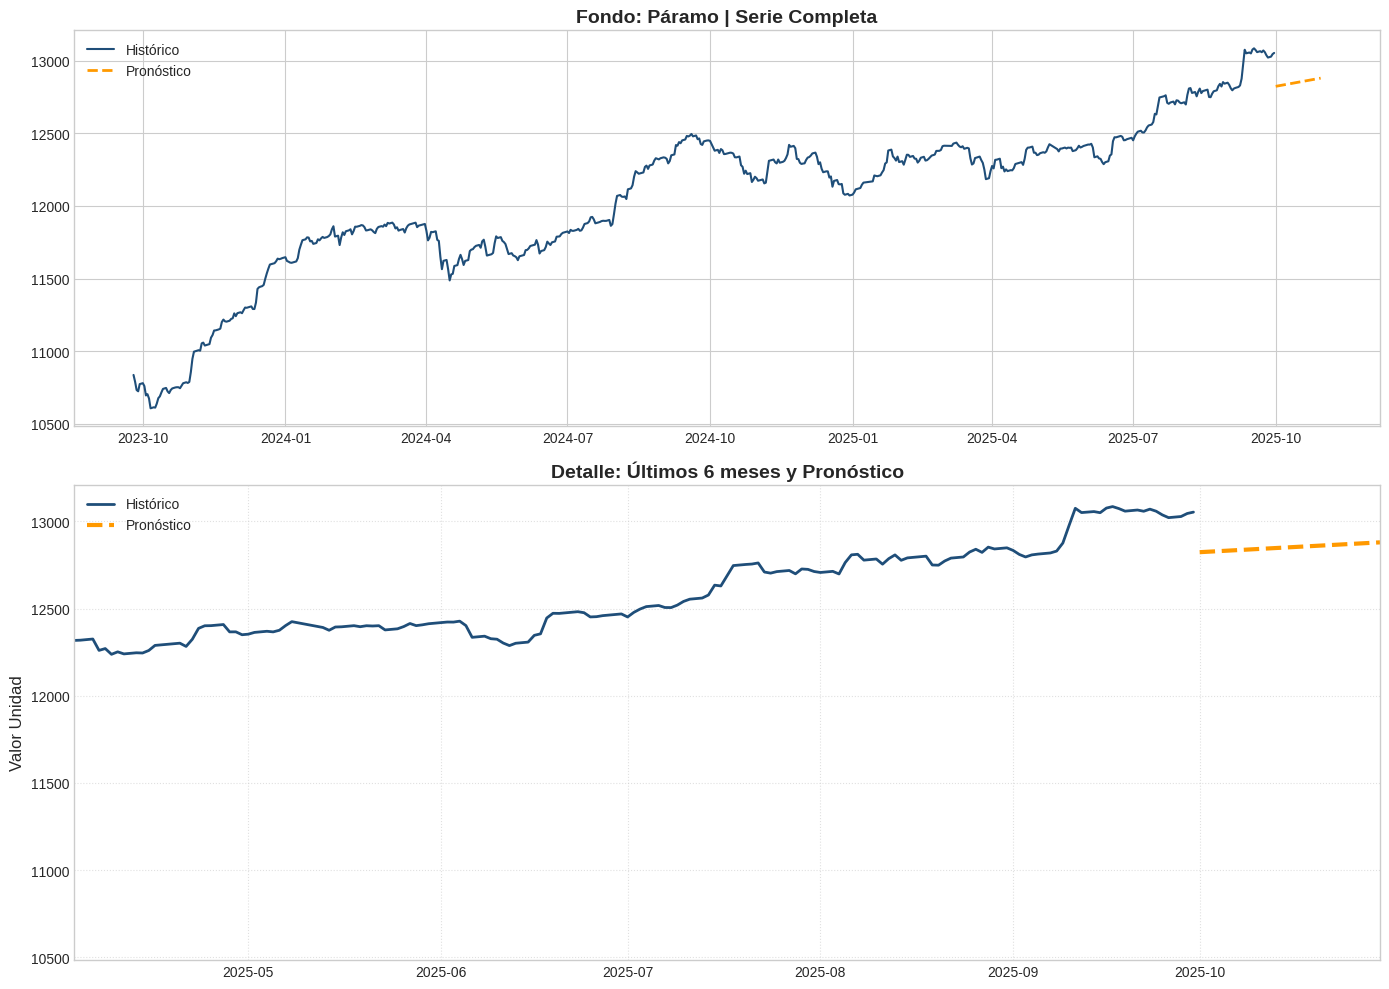

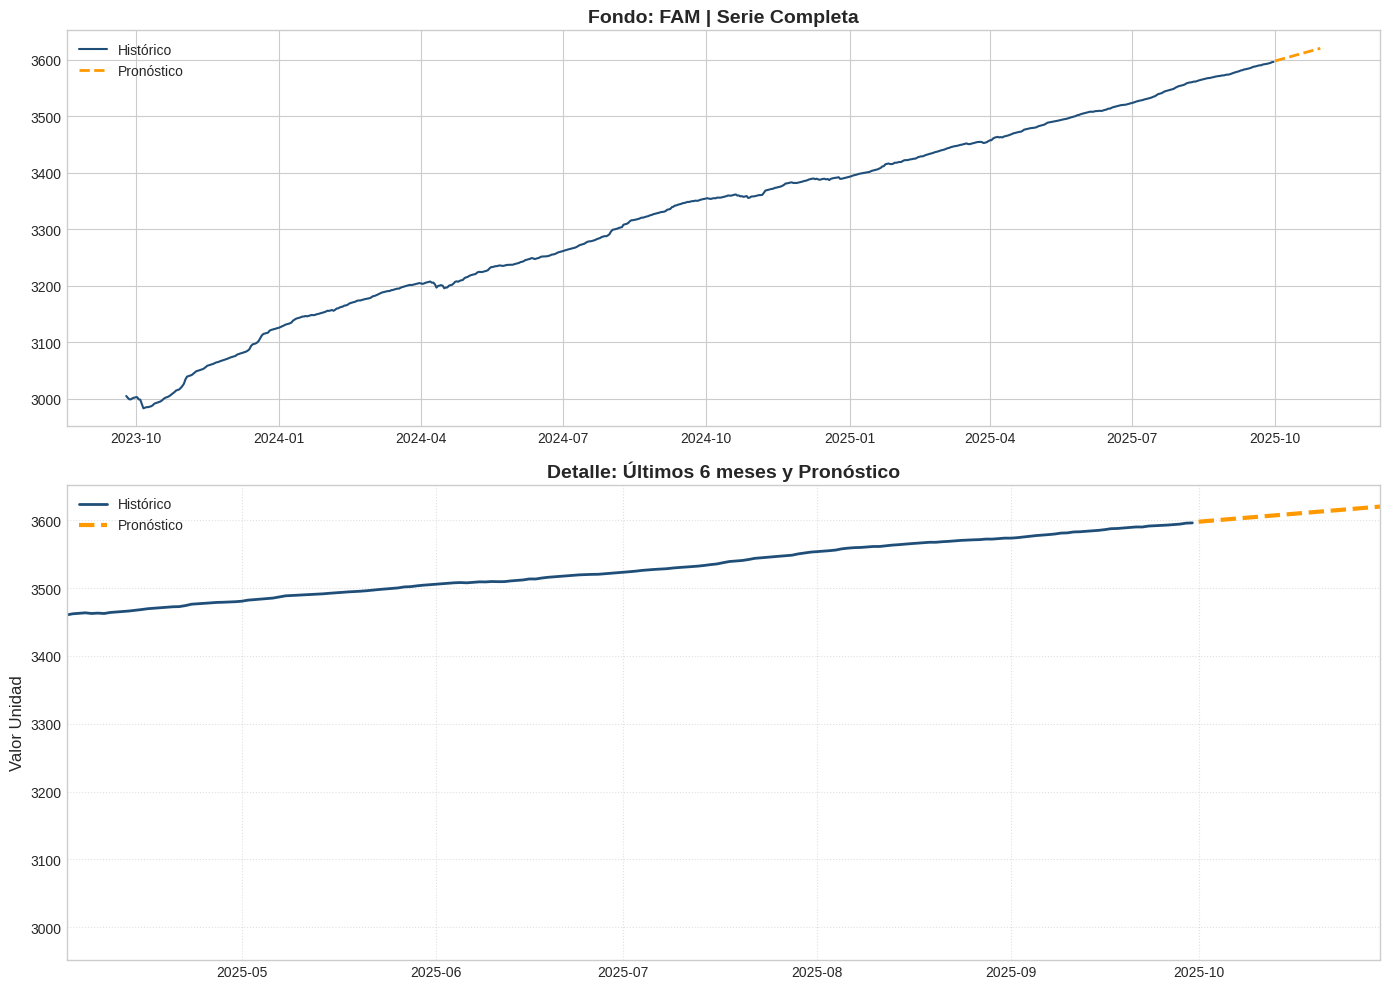

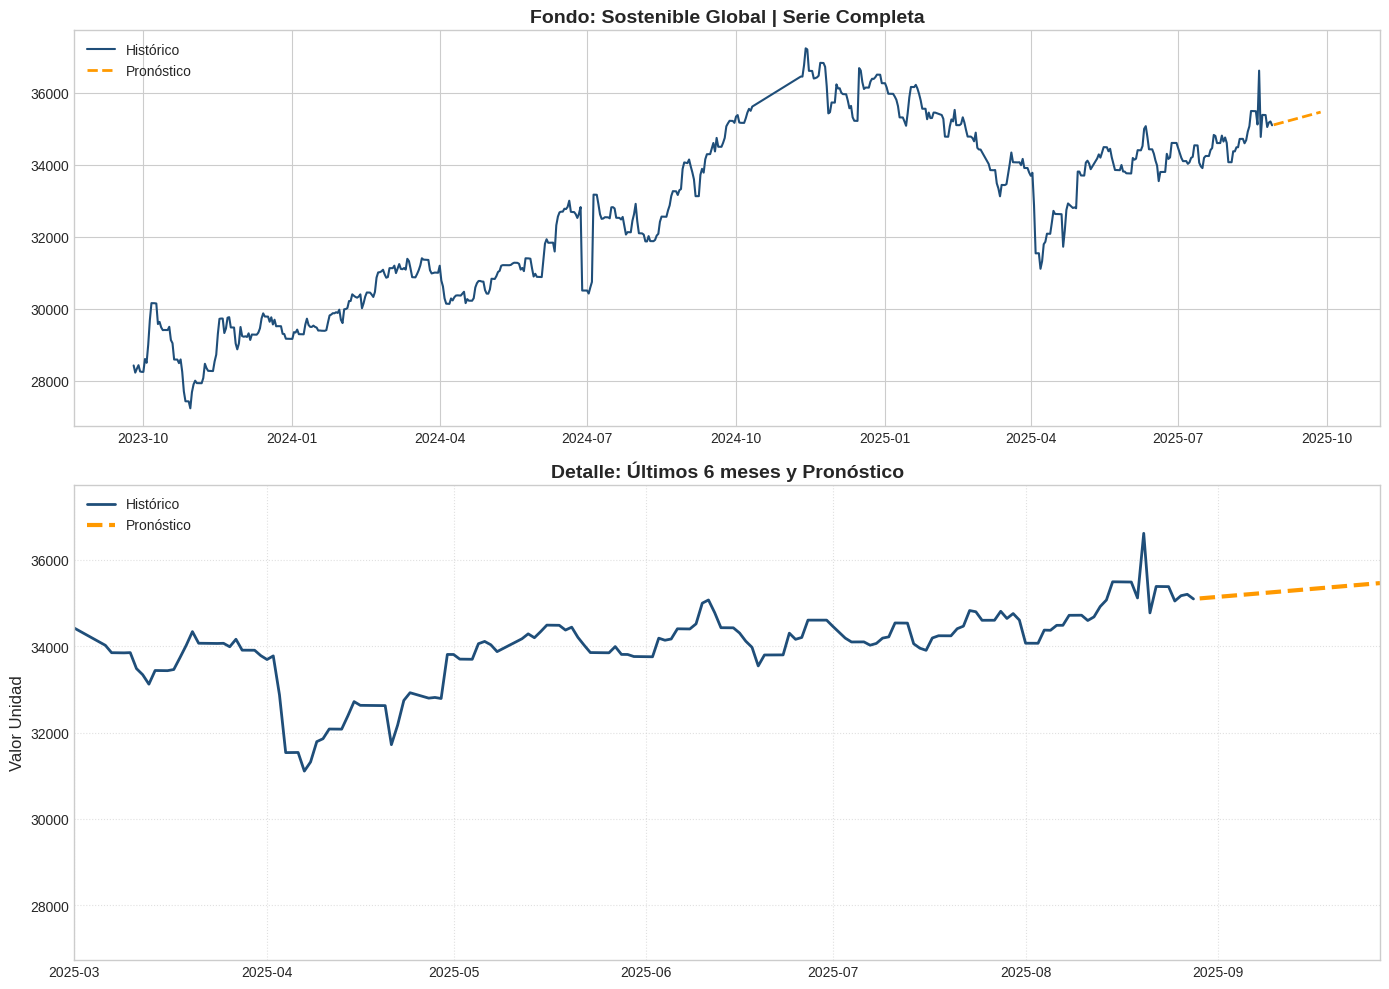

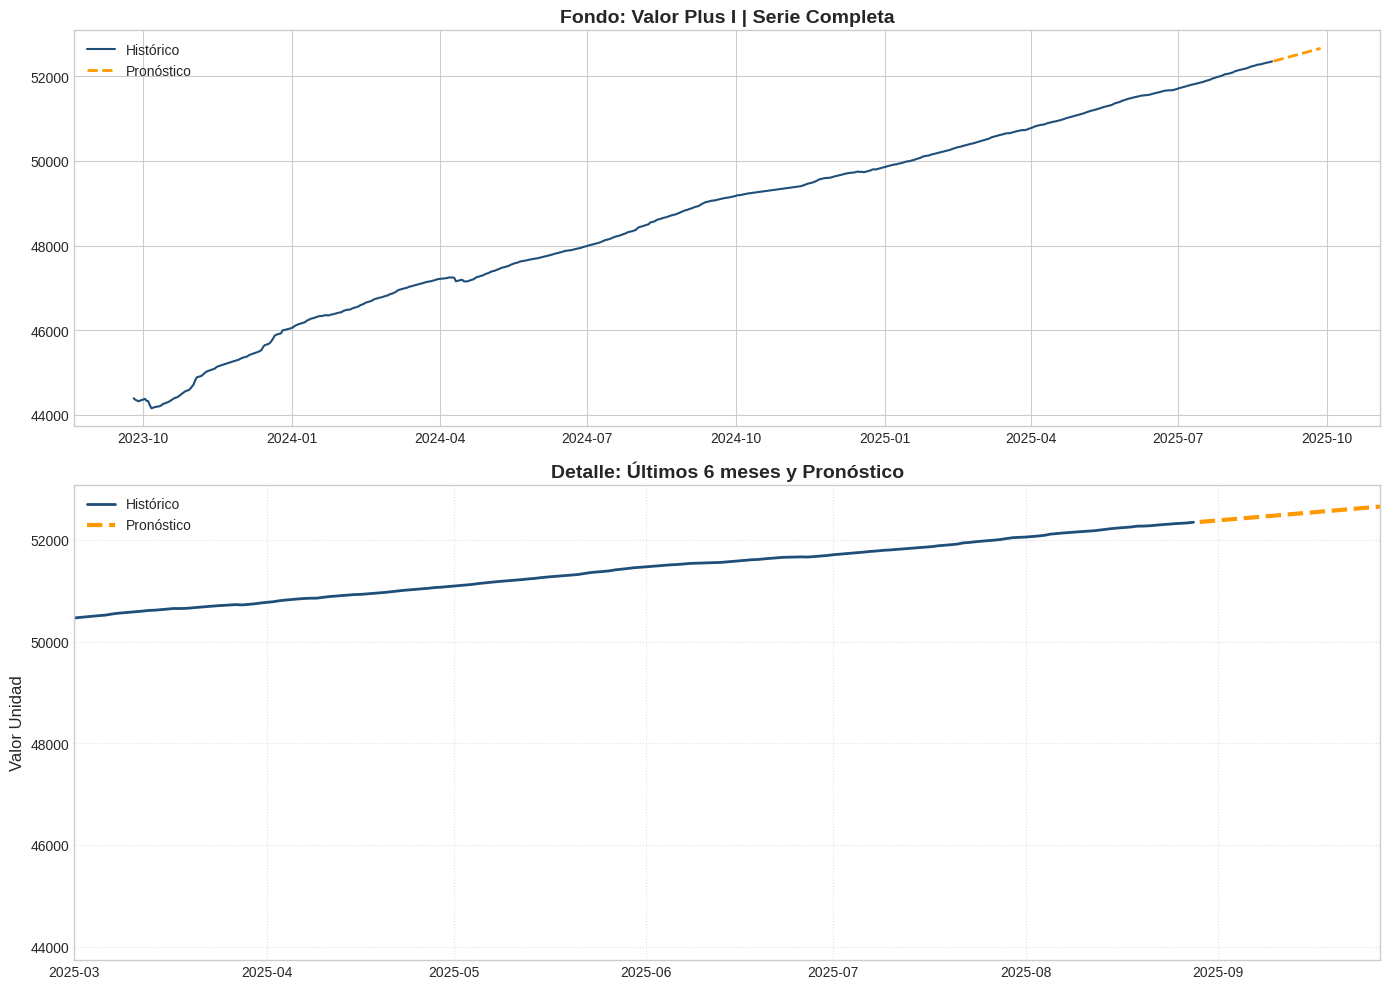

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

def graficar_pronosticos_con_zoom(df, forecasts):
    plt.style.use('seaborn-v0_8-whitegrid')

    for fondo in df['Fondo'].unique():
        df_fondo = df[df['Fondo'] == fondo].sort_values(COL_FECHA)
        forecast_fondo = forecasts[fondo]

        # Crear figura con 2 subplots (1: Serie completa, 2: Zoom)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1.2]})

        # --- SUBPLOT 1: Serie Completa ---
        ax1.plot(df_fondo[COL_FECHA], df_fondo[COL_NIVELES], color='#1f4e79', linewidth=1.5, label='Histórico')
        ax1.plot(forecast_fondo['Fecha'], forecast_fondo['Pronostico'], color='#ff9900', linestyle='--', linewidth=2, label='Pronóstico')
        ax1.set_title(f'Fondo: {fondo} | Serie Completa', fontsize=14, fontweight='bold')
        ax1.legend(loc='upper left')

        # --- SUBPLOT 2: Zoom (Últimos 6 meses + Pronóstico) ---
        ax2.plot(df_fondo[COL_FECHA], df_fondo[COL_NIVELES], color='#1f4e79', linewidth=2, label='Histórico')
        ax2.plot(forecast_fondo['Fecha'], forecast_fondo['Pronostico'], color='#ff9900', linestyle='--', linewidth=3, label='Pronóstico')

        # Definir el rango del zoom (últimos 6 meses desde el fin del histórico)
        start_date = df_fondo[COL_FECHA].max() - timedelta(days=180)
        end_date = forecast_fondo['Fecha'].max()
        ax2.set_xlim(start_date, end_date)

        ax2.set_title(f'Detalle: Últimos 6 meses y Pronóstico', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Valor Unidad', fontsize=12)
        ax2.legend(loc='upper left')
        ax2.grid(True, linestyle=':', alpha=0.6)

        # Formato fechas
        for ax in [ax1, ax2]:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

        plt.tight_layout()
        plt.show()

# Ejecutar
graficar_pronosticos_con_zoom(df_resultados, forecasts)

# Pruebas Ruido Blanco

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox, acorr_breusch_godfrey
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Lista para guardar los resultados
resultados_diagnosticos = []
nlags_to_test = 10 # Desired number of lags for tests

for fondo in df_resultados['Fondo'].unique():
    # 1. Preparar datos históricos
    df_fondo = df_resultados[df_resultados['Fondo'] == fondo].sort_values(COL_FECHA).dropna(subset=[COL_RETORNOS, COL_NIVELES])
    config = models_config[fondo]

    # Initialize residuos as an empty Series to handle cases where no model is found or data is insufficient
    residuos = pd.Series()

    # 2. Obtener residuos según el modelo ganador
    if config['model'] == 'ARIMA':
        if len(df_fondo[COL_RETORNOS]) > 0:
            model = ARIMA(df_fondo[COL_RETORNOS], order=config['order']).fit()
            residuos = model.resid
    else:
        # Prophet (re-ajustamos con los datos históricos para sacar residuos)
        prophet_input_df = df_fondo[[COL_FECHA, COL_NIVELES]].rename(columns={COL_FECHA: 'ds', COL_NIVELES: 'y'})
        if len(prophet_input_df) > 0:
            m = Prophet(**config['params'], daily_seasonality=False, yearly_seasonality=False, weekly_seasonality=False)
            m.fit(prophet_input_df)
            predicciones = m.predict(prophet_input_df)
            residuos = prophet_input_df['y'] - predicciones['yhat']

    # Crucial step: Remove NaNs and Infs from residuals before diagnostic tests
    residuos = residuos.replace([np.inf, -np.inf], np.nan).dropna()

    # Check if there are enough residuals after cleaning for the tests
    # For Breusch-Godfrey, nlags must be < len(residuos) - number_of_exog_variables
    # For sm.add_constant(np.arange(len(residuos))), we have 2 exog variables (constant and time trend)
    # So we need len(residuos) > nlags + 1
    if len(residuos) <= nlags_to_test + 1:
        print(f"Advertencia: No hay suficientes residuos limpios para el fondo '{fondo}' ({len(residuos)}). Saltando pruebas diagnósticas.")
        resultados_diagnosticos.append({
            'Fondo': fondo,
            'Modelo': config['model'],
            'Ljung-Box (p-valor)': np.nan,
            'Breusch-Godfrey (p-valor)': np.nan,
            '¿Ruido Blanco?': 'No disponible'
        })
        continue

    # Adjust nlags dynamically based on remaining residuals
    current_nlags = min(nlags_to_test, len(residuos) - 2) # Ensure nlags < len(residuos) - 2 for BG test
    if current_nlags < 1:
        print(f"Advertencia: Residuos insuficientes para pruebas de autocorrelación para el fondo '{fondo}'.")
        lb_pvalue = np.nan
        bg_pvalue = np.nan
    else:
        # 3. Prueba de Ljung-Box (Autocorrelación)
        # Buscamos que el p-valor > 0.05
        lb_test = acorr_ljungbox(residuos, lags=[current_nlags], return_df=True)
        lb_pvalue = lb_test['lb_pvalue'].iloc[0]

        # 4. Prueba de Breusch-Godfrey (Correlación serial)
        # Necesitamos un modelo lineal básico para correr esta prueba sobre los residuos
        X = sm.add_constant(np.arange(len(residuos)))
        try:
            modelo_ols = sm.OLS(residuos, X).fit()
            bg_test = acorr_breusch_godfrey(modelo_ols, nlags=current_nlags)
            bg_pvalue = bg_test[1]
        except Exception as e:
            print(f"Error al ejecutar Breusch-Godfrey para el fondo '{fondo}': {e}. Asignando NaN.")
            bg_pvalue = np.nan

    is_white_noise = 'Sí' if (lb_pvalue > 0.05 and bg_pvalue > 0.05) else 'No'
    if np.isnan(lb_pvalue) or np.isnan(bg_pvalue): # If any test failed/skipped
        is_white_noise = 'No disponible'

    resultados_diagnosticos.append({
        'Fondo': fondo,
        'Modelo': config['model'],
        'Ljung-Box (p-valor)': round(lb_pvalue, 4),
        'Breusch-Godfrey (p-valor)': round(bg_pvalue, 4),
        '¿Ruido Blanco?': is_white_noise
    })

# --- MOSTRAR RESULTADOS ---
df_diagnostico = pd.DataFrame(resultados_diagnosticos)
print("\n--- DIAGNÓSTICO DE RESIDUOS (PRUEBAS DE RUIDO BLANCO) ---")
print(df_diagnostico.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)



--- DIAGNÓSTICO DE RESIDUOS (PRUEBAS DE RUIDO BLANCO) ---
            Fondo  Modelo  Ljung-Box (p-valor)  Breusch-Godfrey (p-valor) ¿Ruido Blanco?
           Páramo Prophet               0.0000                     0.0000             No
              FAM Prophet               0.0000                     0.0000             No
Sostenible Global   ARIMA               0.1701                     0.2388             Sí
     Valor Plus I Prophet               0.0000                     0.0000             No


Las pruebas de diagnóstico Ljung-Box y Breusch-Godfrey aplicadas a los residuos de los modelos Prophet rechazaron la hipótesis nula de ausencia de autocorrelación ($p < 0.05$). Esto sugiere que, si bien Prophet ofrece un buen ajuste en términos de métricas de error (RMSE, MAE), existe una estructura de dependencia residual no capturada. Este fenómeno es consistente con la naturaleza estocástica de los retornos financieros, sugiriendo que la modelación futura podría beneficiarse de enfoques híbridos, tales como la integración de componentes GARCH para la gestión de la volatilidad o la inclusión de variables macroeconómicas exógenas que capturen ciclos de mercado no detectados por el modelo base